# <center>The delta method and Wald tests</center>
### <center>Alfred Galichon (NYU)</center>
## <center>'math+econ+code' masterclass series: econometrics</center>
#### <center>With python code examples</center>

© 2018–2026 by Alfred Galichon. Past and present support from NSF grant DMS-1716489, ERC grant CoG-866274 are acknowledged, as well as inputs from contributors listed [here](http://www.math-econ-code.org/team).

**If you reuse material from this masterclass, please cite as:**<br>
Alfred Galichon, 'math+econ+code' masterclass series. https://www.math-econ-code.org/

### Learning objectives

* Apply the **delta method** to obtain a confidence interval for a smooth nonlinear function of regression coefficients (the percentage return to one year of schooling), and check it against a nonparametric bootstrap.

* State and use the **Wald statistic** with a robust covariance matrix to test joint restrictions on the coefficients, recovering it as a $\chi^2$ corollary of the asymptotic-normality theory of Lecture 4.

* See both tools as immediate consequences of $\sqrt I(\hat\beta-\beta)\xrightarrow{d}\mathcal N(0,V)$ and a consistent estimate of the sandwich variance $V$.

### References

**[H]** Hansen, B. E. (2022). *Econometrics*. Princeton University Press. Chapters 7 (asymptotic theory and the delta method) and 9 (hypothesis testing and the Wald statistic).

**[vdV]** van der Vaart, A. W. (1998). *Asymptotic Statistics*. Cambridge University Press. Chapter 3 (the delta method).

# Motivation: from coefficients to their nonlinear functions and joint tests

Lecture 4 established that $\sqrt I(\hat\beta-\beta)\xrightarrow{d}\mathcal N(0,V)$, with $V$ consistently estimated by the Eicker–White sandwich. Two questions follow immediately.

* Applied work rarely reports a raw coefficient. We want the **percentage** return to schooling, an elasticity, a ratio: smooth *nonlinear functions* $g(\hat\beta)$. The **delta method** turns asymptotic normality of $\hat\beta$ into asymptotic normality of $g(\hat\beta)$.

* Hypotheses usually restrict *several* coefficients at once. The **Wald statistic** tests such joint restrictions. Both are corollaries of the same limit theory: no new asymptotics required.

## Setup: the Mroz Mincer regression of Lecture 3

We reuse the OLS helper, the heteroskedasticity-robust covariance, and the Mroz (1987) Mincer fit from Lecture 4: $I=428$ working women, log-wage on an intercept, education, experience, and experience squared. (Offline: `pip install wooldridge`.)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from types import SimpleNamespace
import statsmodels.api as sm

def ols(X_i_k, y_i):
    XtX_k_k = X_i_k.T @ X_i_k
    β_k = np.linalg.solve(XtX_k_k, X_i_k.T @ y_i)
    εhat_i = y_i - X_i_k @ β_k
    return SimpleNamespace(β_k=β_k, εhat_i=εhat_i, I=X_i_k.shape[0], K=X_i_k.shape[1],
                           XtXinv_k_k=np.linalg.inv(XtX_k_k))

def vcov_robust(X_i_k, εhat_i, hc='HC0'):
    I, K = X_i_k.shape
    XtXinv_k_k = np.linalg.inv(X_i_k.T @ X_i_k)
    if hc == 'HC0':
        e2_i = εhat_i ** 2
    elif hc == 'HC1':
        e2_i = (I / (I - K)) * εhat_i ** 2
    elif hc in ('HC2', 'HC3'):
        h_i = (X_i_k * (XtXinv_k_k @ X_i_k.T).T).sum(axis=1)
        e2_i = εhat_i ** 2 / (1 - h_i) if hc == 'HC2' else εhat_i ** 2 / (1 - h_i) ** 2
    else:
        raise ValueError(f'unknown hc={hc!r}')
    Ω_k_k = (X_i_k * e2_i[:, None]).T @ X_i_k
    return XtXinv_k_k @ Ω_k_k @ XtXinv_k_k

# Mroz (1987): working women, log-wage ~ 1 + educ + exper + exper^2
url = 'https://vincentarelbundock.github.io/Rdatasets/csv/sampleSelection/Mroz87.csv'
try:
    mroz = pd.read_csv(url)
except Exception:
    import wooldridge
    mroz = wooldridge.data('mroz').rename(columns={'inlf': 'lfp'}).copy()
mroz_w = mroz.loc[mroz['lfp'] == 1].copy()
mroz_w['lwage'] = np.log(mroz_w['wage'])
y_i = mroz_w['lwage'].values
X_i_k = np.column_stack([np.ones(len(mroz_w)), mroz_w['educ'].values,
                         mroz_w['exper'].values, mroz_w['exper'].values ** 2])
var_names = ['intercept', 'educ', 'exper', 'exper^2']
I, K = X_i_k.shape
fit = ols(X_i_k, y_i)
print(f'I = {I}, K = {K}')
print('OLS coefficients:', dict(zip(var_names, fit.β_k.round(4))))


I = 428, K = 4
OLS coefficients: {'intercept': -0.522, 'educ': 0.1075, 'exper': 0.0416, 'exper^2': -0.0008}


# 1. The delta method

## 1.1 Statement

---

**Theorem (Delta method).** Let $\hat\theta_I\in\mathbb{R}^K$ satisfy $\sqrt{I}(\hat\theta_I - \theta)\xrightarrow{d}\mathcal{N}(0,V)$, and let $g:\mathbb{R}^K\to\mathbb{R}^m$ be continuously differentiable at $\theta$ with Jacobian $G(\theta) := \partial g/\partial\theta^\top\big|_\theta\in\mathbb{R}^{m\times K}$. Then
$$
\sqrt{I}\bigl(g(\hat\theta_I) - g(\theta)\bigr)\xrightarrow{d}\mathcal{N}\bigl(0,\,G(\theta)\,V\,G(\theta)^\top\bigr).
$$

---

**Proof sketch.** Differentiability of $g$ at $\theta$ gives the expansion
$$
g(\hat\theta_I) - g(\theta) = G(\theta)(\hat\theta_I - \theta) + o_p\bigl(\lVert\hat\theta_I-\theta\rVert\bigr).
$$
Multiplying by $\sqrt I$, the leading term converges in distribution to $\mathcal{N}(0, GVG^\top)$, and since $\sqrt I\lVert\hat\theta_I-\theta\rVert = O_p(1)$ the remainder is $o_p(1)$; Slutsky concludes. $\square$ (A *single* mean-value point $\tilde\theta_I$ would not be legitimate for vector-valued $g$: the intermediate point differs from component to component. The expansion above avoids the issue entirely.)

## 1.2 Application: percentage return to one year of education

In a log-linear wage equation the coefficient $\beta_{\text{educ}}$ is a *semi-elasticity*: the implied multiplicative wage premium for one additional year of schooling is $e^{\beta_{\text{educ}}}$, i.e., a percentage return of
$$
g(\beta) = 100\bigl(e^{\beta_{\text{educ}}} - 1\bigr).
$$
Apply the delta method with $G(\beta) = (0,\;100\,e^{\beta_{\text{educ}}},\;0,\;0)$:
$$
\widehat{\operatorname{Var}}\bigl(g(\hat\beta)\bigr) = G(\hat\beta)\,\widehat{\operatorname{Var}}(\hat\beta)\,G(\hat\beta)^\top
= 100^2\,e^{2\hat\beta_{\text{educ}}}\,\widehat{\operatorname{Var}}(\hat\beta_{\text{educ}}).
$$

In [2]:
β_educ_hat = fit.β_k[1]
VHC1_k_k = vcov_robust(X_i_k, fit.εhat_i, 'HC1')
var_β_educ = VHC1_k_k[1, 1]

# Point estimate of g(β)
g_hat = 100 * (np.exp(β_educ_hat) - 1)

# Delta-method standard error
G_grad = 100 * np.exp(β_educ_hat)
se_g = np.sqrt(G_grad ** 2 * var_β_educ)

z = stats.norm.ppf(0.975)
ci_lo, ci_hi = g_hat - z * se_g, g_hat + z * se_g
print(f'β̂_educ                                  = {β_educ_hat:.4f}')
print(f'percentage return per year of schooling = {g_hat:.2f}%')
print(f'delta-method s.e.                       = {se_g:.3f}')
print(f'95% CI                                  = [{ci_lo:.2f}%, {ci_hi:.2f}%]')


β̂_educ                                  = 0.1075
percentage return per year of schooling = 11.35%
delta-method s.e.                       = 1.472
95% CI                                  = [8.46%, 14.23%]


## 1.3 Numerical verification of the delta method

To confirm that the delta-method approximation is reliable at this $I$, we resample the Mroz data with replacement (a nonparametric bootstrap), compute $g(\hat\beta)$ on each resample, and compare the bootstrap standard deviation to the delta-method standard error.

In [3]:
rng = np.random.default_rng(2026)
R = 5_000
g_r = np.empty(R)
for r in range(R):
    istar_i = rng.integers(0, I, size=I)
    fb = ols(X_i_k[istar_i], y_i[istar_i])
    g_r[r] = 100 * (np.exp(fb.β_k[1]) - 1)

print(f'delta-method  s.e.   = {se_g:.4f}')
print(f'bootstrap     s.d.   = {g_r.std():.4f}')


delta-method  s.e.   = 1.4719
bootstrap     s.d.   = 1.4641


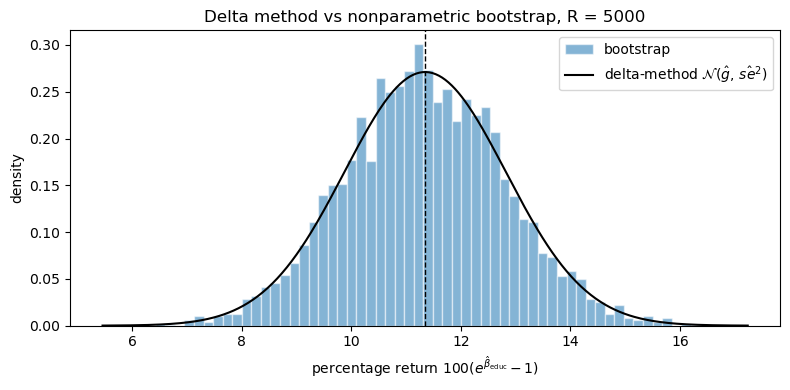

In [4]:
fig, ax = plt.subplots(figsize=(8, 4.0))
ax.hist(g_r, bins=60, density=True, alpha=0.55, edgecolor='white', label='bootstrap')
x_g = np.linspace(g_hat - 4*se_g, g_hat + 4*se_g, 400)
ax.plot(x_g, stats.norm.pdf(x_g, loc=g_hat, scale=se_g), 'k-', lw=1.5,
        label=r'delta-method $\mathcal{N}(\hat g,\,\hat{se}^2)$')
ax.axvline(g_hat, color='k', ls='--', lw=1.0)
ax.set_xlabel(r'percentage return $100(e^{\hat\beta_{\rm educ}} - 1)$')
ax.set_ylabel('density')
ax.set_title(r'Delta method vs nonparametric bootstrap, R = ' + f'{R}')
ax.legend()
plt.tight_layout()
plt.show()


The two distributions are nearly indistinguishable: for this smooth, monotone transformation and this sample, the delta-method approximation is extremely accurate. (The bootstrap here corroborates the shape and standard deviation of the sampling distribution; it does not by itself establish the coverage of the reported interval.) The agreement deteriorates when the function is highly nonlinear or evaluated near a singularity of the gradient; the bootstrap remains a useful diagnostic in such cases, and we return to it in **Lecture 12**.

# 2. Wald hypothesis testing with robust covariance

## 2.1 The Wald statistic

Consider a smooth restriction $H_0: r(\beta) = 0$ for $r:\mathbb{R}^K\to\mathbb{R}^Q$ continuously differentiable, with Jacobian $R(\beta) := \partial r/\partial\beta^\top\big|_\beta$. The Wald statistic is
$$
W := r(\hat\beta)^\top\bigl[R(\hat\beta)\,\widehat{\operatorname{Var}}(\hat\beta)\,R(\hat\beta)^\top\bigr]^{-1} r(\hat\beta).
$$

---

**Theorem.** Under $H_0$ and the conditions of Lecture 4, §2, with $I\,\widehat{\operatorname{Var}}(\hat\beta)\xrightarrow{p}V$, $W\xrightarrow{d}\chi^2_Q$.

---

**Proof.** Combine the delta method (giving $\sqrt I\,r(\hat\beta)\xrightarrow{d}\mathcal{N}(0,RVR^\top)$ under $H_0$) with the consistency of the variance estimator and Slutsky's theorem; the resulting quadratic form in a Gaussian vector with its true precision matrix has a $\chi^2$ limit. $\square$

For a *linear* restriction $H_0: R\beta = r_0$ with $R\in\mathbb{R}^{Q\times K}$, the Wald statistic specializes to
$$
W = (R\hat\beta - r_0)^\top\bigl[R\,\widehat{\operatorname{Var}}(\hat\beta)\,R^\top\bigr]^{-1}(R\hat\beta - r_0).
$$
This is the asymptotic counterpart of the exact $F$-test of Lecture 3. The relation between the two deserves care. When $\widehat{\operatorname{Var}}(\hat\beta)$ is the *classical* homoskedastic matrix $\hat\sigma^2(X^\top X)^{-1}$, the textbook $F$-statistic is exactly $W/Q$: an algebraic identity, not an approximation. That identity does **not** carry over to the HC1 covariance used in the application below: the robust Wald statistic and the classical $F$ are different statistics, numerically and in finite-sample distribution, agreeing only in the limit. Under $H_0$, $W\xrightarrow{d}\chi^2_Q$ and so $W/Q\xrightarrow{d}\chi^2_Q/Q$, which is the $F_{Q,I-K}$ limit as $I-K\to\infty$; that shared limit is the whole of the connection when the covariance is robust.

## 2.2 Application: joint significance of the slopes

We test $H_0: \beta_{\text{educ}} = \beta_{\text{exper}} = \beta_{\text{exper}^2} = 0$ in the Mroz Mincer regression, using the HC1 covariance matrix.

In [5]:
# Joint test on the three slopes
Q = 3
R_q_k = np.zeros((Q, K))
R_q_k[0, 1] = 1; R_q_k[1, 2] = 1; R_q_k[2, 3] = 1
r_q = np.zeros(Q)

VHC1_k_k = vcov_robust(X_i_k, fit.εhat_i, 'HC1')
dev_q = R_q_k @ fit.β_k - r_q
W = dev_q @ np.linalg.inv(R_q_k @ VHC1_k_k @ R_q_k.T) @ dev_q
p_W = 1 - stats.chi2.cdf(W, df=Q)

print(f'Wald statistic              = {W:.4f}')
print(f'asymptotic χ²_{Q} 95% crit. = {stats.chi2.ppf(0.95, Q):.4f}')
print(f'p-value                     = {p_W:.4e}')

# Compare to the exact F-statistic from Lecture 3 (classical SE)
sm_HC1 = sm.OLS(y_i, X_i_k).fit(cov_type='HC1')
W_sm = sm_HC1.wald_test(R_q_k, scalar=True).statistic
print(f'\nstatsmodels HC1 Wald = {W_sm:.4f}  (matches DIY)')


Wald statistic              = 81.8981
asymptotic χ²_3 95% crit. = 7.8147
p-value                     = 0.0000e+00

statsmodels HC1 Wald = 81.8981  (matches DIY)


# Looking ahead

The delta method and the Wald statistic close the asymptotic-inference loop for OLS: point estimates and their sandwich variance (Lecture 4), smooth nonlinear functions of them (delta), and joint restrictions (Wald).

* The next lecture (**Lecture 7, panel data**) turns to repeated observations on the same units; the within transformation and cluster-robust inference reuse exactly this asymptotic machinery.

* The same delta/Wald template carries over, essentially unchanged, to maximum likelihood (**Lecture 8**), GMM (**Lecture 9**), and machine-learning-based estimators (**Lecture 13**): a Gaussian limit for the estimator and a sandwich for its variance is all either tool ever needs.